In [1]:
import os
import sys
sys.path.insert(0, '/home/aiscuser/verl')
import torch
from verl.third_party.sglang.entrypoint import CustomEngine
from verl.utils.dataset.rl_dataset import RLHFDataset, collate_fn
os.environ["SGLANG_BLOCK_NONZERO_RANK_CHILDREN"] = "0"
from transformers import AutoTokenizer, AutoProcessor
from uuid import uuid4

/opt/conda/envs/ptca/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-05-10 17:57:46,613	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


INFO 05-10 17:57:47 __init__.py:190] Automatically detected platform rocm.
WARNING 05-10 17:57:47 rocm.py:33] `fork` method is not supported by ROCm. VLLM_WORKER_MULTIPROC_METHOD is overridden to `spawn` instead.
WARNING 05-10 17:57:47 rocm.py:33] `fork` method is not supported by ROCm. VLLM_WORKER_MULTIPROC_METHOD is overridden to `spawn` instead.


In [17]:
engine = CustomEngine(
    model_path='meta-llama/Llama-3.1-8B-Instruct',
    dtype=torch.bfloat16,
    mem_fraction_static=0.4,
    base_gpu_id=0,
    gpu_id_step=1,
    max_running_requests=128,
    cuda_graph_max_bs=128,
    tp_size=4,
    enable_mixed_chunk=True,
    node_rank=0,
    stream_interval=256,
    nnodes=1,
    enable_torch_compile=False,
)


INFO 05-10 18:03:26 __init__.py:190] Automatically detected platform rocm.
INFO 05-10 18:03:26 __init__.py:190] Automatically detected platform rocm.
INFO 05-10 18:03:26 __init__.py:190] Automatically detected platform rocm.
INFO 05-10 18:03:26 __init__.py:190] Automatically detected platform rocm.
INFO 05-10 18:03:26 __init__.py:190] Automatically detected platform rocm.
node-0:112877:112877 [0] NCCL INFO Bootstrap : Using eth0:100.64.152.128<0>
node-0:112877:112877 [0] NCCL INFO NET/Plugin : dlerror=librccl-net.so: cannot open shared object file: No such file or directory No plugin found (librccl-net.so), using internal implementation
node-0:112877:112877 [0] NCCL INFO Kernel version: 5.15.0-1073-azure
node-0:112877:112877 [0] NCCL INFO ROCr version 1.14
node-0:112877:112877 [0] NCCL INFO Dmabuf feature disabled without NCCL_DMABUF_ENABLE=1
RCCL version 2.20.5+hip6.2 HEAD:45b618a+
node-0:112878:112878 [1] NCCL INFO ROCr version 1.14
node-0:112878:112878 [1] NCCL INFO Dmabuf feature d

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  25% Completed | 1/4 [00:00<00:00,  8.98it/s]
Loading safetensors checkpoint shards:  50% Completed | 2/4 [00:00<00:00,  3.39it/s]
Loading safetensors checkpoint shards:  50% Completed | 2/4 [00:00<00:00,  3.39it/s]
Loading safetensors checkpoint shards:  75% Completed | 3/4 [00:01<00:00,  2.40it/s]
Loading safetensors checkpoint shards:  75% Completed | 3/4 [00:01<00:00,  2.40it/s]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:01<00:00,  2.13it/s]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:01<00:00,  2.43it/s]

Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:01<00:00,  2.13it/s]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:01<00:00,  2.43it/s]

100%|██████████| 19/19 [00:09<00:00,  1.98it/s]


In [50]:
import asyncio
from typing import List, Dict, Optional, Union
from sglang.srt.managers.io_struct import GenerateReqInput, AbortReq
from sglang.srt.entrypoints.verl_engine import VerlEngine as VerlEngineBase
from sglang.srt.entrypoints.verl_engine import _preprocess_tensor_for_update_weights
from sglang.srt.server import Engine
from sglang.srt.utils import MultiprocessingSerializer, broadcast_pyobj
from sglang.srt.model_executor.model_runner import LocalSerializedTensor
import time

async def get_first_value(async_gen):
    return await async_gen.__anext__()

async def get_first_n_results(self, tasks, num_returns):
    outputs = {}
    completed_oids = []
    completed_rids = []
    all_tasks = [task for task_dict in tasks.values() for task in task_dict.values()]
    for oid in tasks.keys():
        outputs[oid] = {}

    queue_stat = []
    for task in asyncio.as_completed(all_tasks):
        result = await task
        rid = result['meta_info']['id']
        oid = rid.split('_nid')[0]
        outputs[oid][rid] = result
        completed_rids.append(rid)
        tasks[oid].pop(rid)
        queue_stat.append((time.time(), num_returns - len(completed_rids)))
        if len(tasks[oid].keys()) == 0:
            completed_oids.append(oid)
            tasks.pop(oid)
        if len(completed_oids) >= num_returns:
            break

    for oid, task_dict in tasks.items():
        for rid in task_dict.keys():
            self.tokenizer_manager.abort_request(rid)



    # Wait for idle
    while True:
        # print(f'waiting for idle')
        internal_state = await self.tokenizer_manager.get_internal_state()
        if internal_state['is_idle']:
            # print(f'idle')
            break
    
    # Scavenge incomplete results
    incomplete_tasks = [task for task_dict in tasks.values() for task in task_dict.values()]



    await asyncio.sleep(1)
    for task in incomplete_tasks:
        if task.done():
            result = await task
            incomplete_tasks.remove(task)
            rid = result['meta_info']['id']
            oid = rid.split('_nid')[0]
            outputs[oid][rid] = result
            finish_reason = result['meta_info'].get('finish_reason', {type: ''})
            # to_delete_rids.remove(rid)
            if finish_reason['type'] != 'abort':
                completed_rids.append(rid)
                tasks[oid].pop(rid)
                if len(tasks[oid].keys()) == 0:
                    completed_oids.append(oid)
                    tasks.pop(oid)
        else:
            task.cancel()

    partial_outputs = self.gather_partial_outputs()

    self.tokenizer_manager.clear_queue()
    for output in partial_outputs:
        rid = output['meta_info']['id']
        oid = rid.split('_nid')[0]
        outputs[oid][rid] = output

    return outputs, queue_stat

def custom_generate(
    self,
    # The input prompt. It can be a single prompt or a batch of prompts.
    prompt: Optional[List[str]] = None,
    sampling_params: Optional[Union[List[Dict], Dict]] = None,
    # The token ids for text; one can either specify text or input_ids.
    input_ids: Optional[Union[List[List[int]], List[int]]] = None,
    # The image input. It can be a file name, a url, or base64 encoded string.
    # See also python/sglang/srt/utils.py:load_image.
    image_data: Optional[Union[List[str], str]] = None,
    return_logprob: Optional[Union[List[bool], bool]] = False,
    logprob_start_len: Optional[Union[List[int], int]] = None,
    top_logprobs_num: Optional[Union[List[int], int]] = None,
    token_ids_logprob: Optional[Union[List[List[int]], List[int]]] = None,
    lora_path: Optional[List[Optional[str]]] = None,
    custom_logit_processor: Optional[Union[List[str], str]] = None,
    stream: bool = False,
    rid: Optional[Union[List[str], str]] = None,
    num_returns: Optional[int] = None,
) -> Union[Dict]:
    if prompt is not None:
        batch_size = len(prompt)
    if input_ids is not None:
        batch_size = len(input_ids)
    loop = asyncio.get_event_loop()
    
    # n = sampling_params.get("n", 1) if sampling_params is not None else 1
    sampling_params_ = sampling_params[0].copy()
    sampling_params_['n'] = 1
    assert num_returns is not None, "num_returns should be provided"
    assert rid is not None, "rid should be provided"

    original_rids = list(set([rid.split('_nid')[0] for rid in rid]))
    all_rids = rid


    objs = {}
    tasks = {}
    for oid in original_rids:
        objs[oid] = {}
        tasks[oid] = {}
    for i, rid in enumerate(all_rids):
        oid = rid.split('_nid')[0]
        tmp_sampling_params = sampling_params[i].copy()
        max_length = 18 * 1024
        context_length = len(input_ids[i])
        objs[oid][rid] = GenerateReqInput(
            text=None,
            input_ids=input_ids[i],
            sampling_params=tmp_sampling_params,
            image_data=None,
            return_logprob=return_logprob,
            logprob_start_len=logprob_start_len,
            top_logprobs_num=top_logprobs_num,
            token_ids_logprob=token_ids_logprob,
            lora_path=lora_path,
            custom_logit_processor=custom_logit_processor,
            stream=False,
            rid=rid,
        )
        generator = self.tokenizer_manager.generate_request(objs[oid][rid], None)
        task = loop.create_task(get_first_value(generator))
        tasks[oid][rid] = task



    outputs, queue_stat = loop.run_until_complete(self.get_first_n_results(tasks, num_returns))

    return outputs, queue_stat

engine.custom_generate = custom_generate.__get__(engine, CustomEngine)
engine.get_first_n_results = get_first_n_results.__get__(engine, CustomEngine)

In [20]:
tokenizer = AutoTokenizer.from_pretrained('meta-llama/Llama-3.1-8B-Instruct')
processor = AutoProcessor.from_pretrained('meta-llama/Llama-3.1-8B-Instruct')
dataset = RLHFDataset(
    parquet_files=['/home/aiscuser/data/dapo-math-17k.parquet'],
    tokenizer=tokenizer,
    processor=processor,
    prompt_key='prompt',
    max_prompt_length=2048,
    filter_prompts=True,
    return_raw_chat=False,
    truncation='error',
    filter_overlong_prompts=False
    )

dataset len: 1791700


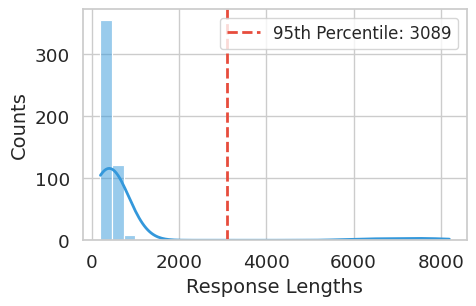

Number of samples: 512
Min length: 201
Max length: 8192
Mean length: 746.17
Median length: 394.50
90th percentile: 3089.35
Standard deviation: 1484.57


In [138]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

lengths = max_new_tokens_list

# Calculate the 90th percentile
percentile_90 = np.percentile(lengths, 95)

# Set the Seaborn style
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.2)

# Create a DataFrame for the lengths
df = pd.DataFrame({'Token Lengths': lengths})

# Create the figure
plt.figure(figsize=(5, 3.3))

# Create the seaborn histogram plot with KDE
ax = sns.histplot(data=df, x='Token Lengths', kde=True, color='#3498db', bins=30, line_kws={'linewidth': 2})

# Add the 90th percentile vertical line
plt.axvline(x=percentile_90, color='#e74c3c', linestyle='--', linewidth=2, label=f'95th Percentile: {percentile_90:.0f}')

# Add labels and title
# plt.title('Distribution of Output Token Lengths', fontsize=18)
plt.xlabel('Response Lengths', fontsize=14)
plt.ylabel('Counts', fontsize=14)

# Add a legend
plt.legend(fontsize=12)

# Tighten the layout
plt.tight_layout()
plt.savefig('output_token_lengths.pdf', bbox_inches='tight')

# Show the plot
plt.show()

# Print basic statistics for context
print(f"Number of samples: {len(lengths)}")
print(f"Min length: {min(lengths)}")
print(f"Max length: {max(lengths)}")
print(f"Mean length: {np.mean(lengths):.2f}")
print(f"Median length: {np.median(lengths):.2f}")
print(f"90th percentile: {percentile_90:.2f}")
print(f"Standard deviation: {np.std(lengths):.2f}")

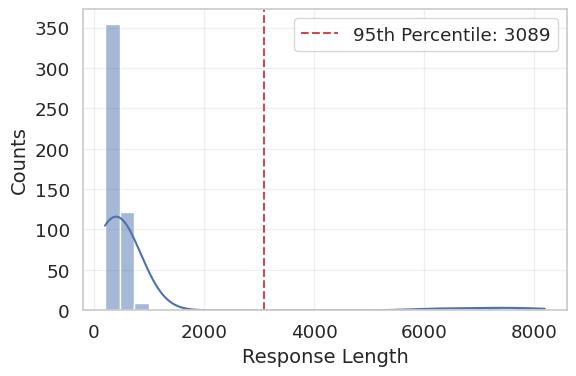

Generated max_new_tokens statistics:
Min: 201
Max: 8192
Mean: 746.17
Median: 394.50
Std Dev: 1484.57
Percent of values > 80% of max: 3.71%
10th percentile: 256
25th percentile: 318
50th percentile: 394
75th percentile: 498
90th percentile: 650
95th percentile: 3089
99th percentile: 7792
Modified Gumbel distribution for max_new_tokens created: max_new_tokens_list


In [112]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Set parameters for Gumbel distribution
# For a Gumbel distribution with desired min, mean, and max
# We need to compute the location and scale parameters

# Given constraints
min_tokens = 200
mean_tokens = 400
max_tokens = 8192

# First approach: Generate a stretched Gumbel distribution that reaches the max
# To stretch the distribution, we'll use a specific technique

# Function to generate a transformation of Gumbel that better reaches our desired max
def generate_better_gumbel(min_val, mean_val, max_val, size=512, seed=42):
    np.random.seed(seed)
    
    # Calculate parameters for initial Gumbel
    gamma = np.euler_gamma
    
    # Use a larger scale to make the tail longer
    scale = (mean_val - min_val) / 2
    location = mean_val - scale * gamma
    
    # Generate raw Gumbel samples
    raw_samples = stats.gumbel_r.rvs(loc=location, scale=scale, size=size*3)  # Generate more samples than needed
    
    # Filter samples to keep only those in our desired range
    valid_samples = raw_samples[(raw_samples >= min_val) & (raw_samples <= max_val)]
    
    # If we don't have enough samples, use clipping approach as fallback
    if len(valid_samples) < size:
        # Generate regular Gumbel
        regular_samples = stats.gumbel_r.rvs(loc=location, scale=scale, size=size)
        samples = np.clip(regular_samples, min_val, max_val)
    else:
        # Take the first 'size' valid samples
        samples = valid_samples[:size]
    
    # Ensure we still reach the max by setting at least one value to max_val
    if np.max(samples) < max_val * 0.9:  # If max is not at least 90% of desired max
        # Set at least one value to be the max
        samples[-1] = max_val
        # Add a few more high values to ensure the distribution reaches toward max
        high_percentile_samples = np.random.uniform(max_val*0.7, max_val, size=int(size*0.05))
        indices = np.random.choice(size, size=len(high_percentile_samples), replace=False)
        samples[indices] = high_percentile_samples
    
    return np.round(samples).astype(int)

# Generate our improved Gumbel distribution
max_new_tokens_list = generate_better_gumbel(min_tokens, mean_tokens, max_tokens)

# Apply min and max constraints as a safety measure
max_new_tokens_list = np.clip(max_new_tokens_list, min_tokens, max_tokens)

# Calculate what percentage of values are near max
near_max_pct = np.mean(max_new_tokens_list > max_tokens * 0.8) * 100

# Calculate the 90th percentile
percentile_95 = np.percentile(max_new_tokens_list, 95)

# Visualize the distribution
plt.figure(figsize=(6, 4))
sns.histplot(max_new_tokens_list, bins=30, kde=True)
# Add the 90th percentile vertical line
plt.axvline(x=percentile_95, color='r', linestyle='--', label=f'95th Percentile: {percentile_95:.0f}')
# plt.axvline(x=min_tokens, color='r', linestyle='--', label=f'Min: {min_tokens}')
# plt.axvline(x=mean_tokens, color='g', linestyle='--', label=f'Mean: {mean_tokens}')
# plt.axvline(x=max_tokens, color='y', linestyle='--', label=f'Target Max: {max_tokens}')
# plt.axvline(x=np.mean(max_new_tokens_list), color='b', linestyle='--', 
        #    label=f'Actual Mean: {np.mean(max_new_tokens_list):.1f}')
# plt.title('Distribution of max_new_tokens (Modified Gumbel)', fontsize=16)
plt.xlabel('Response Length', fontsize=14)
plt.ylabel('Counts', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print distribution statistics
print(f"Generated max_new_tokens statistics:")
print(f"Min: {np.min(max_new_tokens_list)}")
print(f"Max: {np.max(max_new_tokens_list)}")
print(f"Mean: {np.mean(max_new_tokens_list):.2f}")
print(f"Median: {np.median(max_new_tokens_list):.2f}")
print(f"Std Dev: {np.std(max_new_tokens_list):.2f}")
print(f"Percent of values > 80% of max: {near_max_pct:.2f}%")

# Percentiles
percentiles = [10, 25, 50, 75, 90, 95, 99]
percentile_values = np.percentile(max_new_tokens_list, percentiles)
for p, v in zip(percentiles, percentile_values):
    print(f"{p}th percentile: {v:.0f}")
    
print("Modified Gumbel distribution for max_new_tokens created: max_new_tokens_list")

In [48]:
input_ids = []
sampling_params = {
        'top_k': -1,
        'top_p': 1,
        'temperature': 0.8,
        'max_new_tokens': 16 * 1024,
        'n': 1,
        'min_new_tokens': 1,
        'ignore_eos': True,
        'skip_special_tokens': True,
    }
rids = []
sampling_params_list = []
for i in range(0, 512):
    data = dataset[i+512]
    input_ids.append(data['input_ids'].tolist())
    rids.append(f'req{str(uuid4().hex)[:8]}_nid{str(uuid4().hex)[:8]}')
    sampling_params_ = sampling_params.copy()
    sampling_params_['max_new_tokens'] = max_new_tokens_list[i]
    sampling_params_['min_new_tokens'] = max_new_tokens_list[i] - 1
    assert sampling_params_['max_new_tokens'] > sampling_params_['min_new_tokens'], f"max_new_tokens {sampling_params_['max_new_tokens']} should be greater than min_new_tokens {sampling_params_['min_new_tokens']}"
    sampling_params_list.append(sampling_params_)


In [51]:
output, queue_stat = engine.custom_generate(
    input_ids=input_ids,
    sampling_params=sampling_params_list,
    rid=rids,
    num_returns=512,
    return_logprob=True,
)

Clear queue
Clear queue
Clear queue
Clear queue


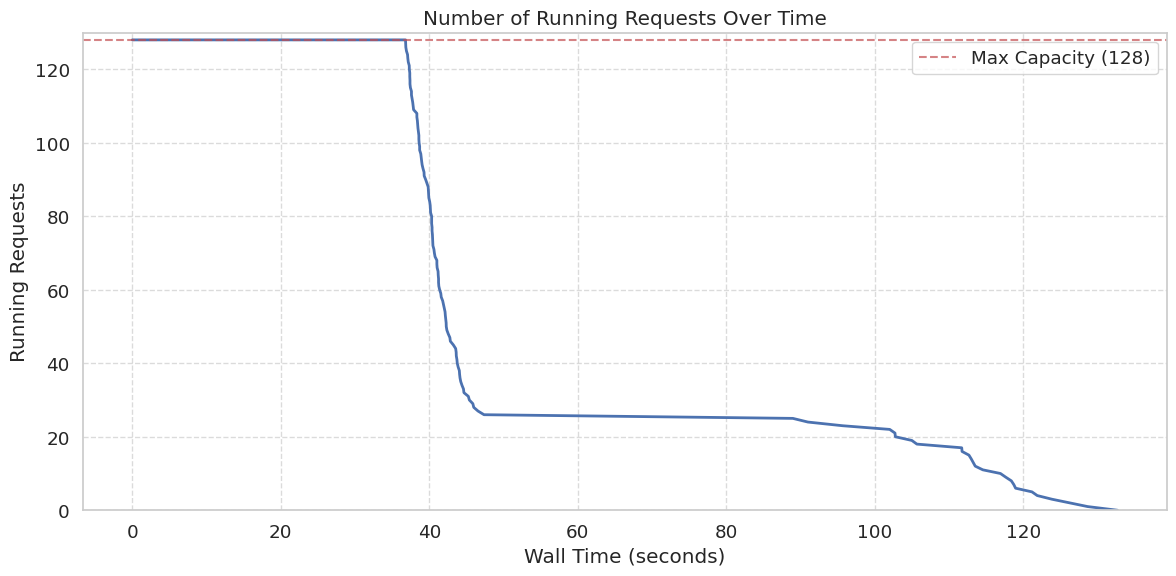

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# Extract timestamps and remaining requests from queue_stat
timestamps = [stat[0] for stat in queue_stat]
remaining_requests = [stat[1] for stat in queue_stat]

# Convert to relative time (starting from 0)
start_time = timestamps[0]
relative_times = [t - start_time for t in timestamps]

# Calculate running requests (128 + remaining requests beyond 128)
# If remaining requests > 128, then we're at max capacity (128)
# Otherwise, we calculate 256 - remaining to get current running
running_requests = []
total_requests = 512

for remaining in remaining_requests:
    if remaining > 128:
        # We're at max capacity (128 running)
        running_requests.append(128)
    else:
        # Calculate actual running requests
        running_requests.append(remaining)

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(relative_times, running_requests, 'b-', linewidth=2)
plt.xlabel('Wall Time (seconds)')
plt.ylabel('Running Requests')
plt.title('Number of Running Requests Over Time')
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0, 130)  # Set y-axis limits with a little headroom above 128

# Add horizontal line at max capacity (128)
plt.axhline(y=128, color='r', linestyle='--', alpha=0.7, label='Max Capacity (128)')

plt.legend()
plt.tight_layout()
plt.show()

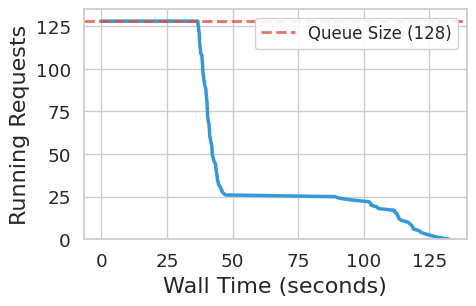

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set the Seaborn style and context
sns.set(style="whitegrid")
sns.set_context("notebook", font_scale=1.2)

# Create a DataFrame for better plotting with Seaborn
data = pd.DataFrame({
    'Wall Time (seconds)': relative_times,
    'Running Requests': running_requests
})

# Create the enhanced plot
plt.figure(figsize=(5, 3.3))
ax = sns.lineplot(
    data=data, 
    x='Wall Time (seconds)', 
    y='Running Requests',
    linewidth=2.5,
    color='#3498db'
)

# Add a horizontal line at max capacity
plt.axhline(y=128, color='#e74c3c', linestyle='--', linewidth=2, alpha=0.8, label='Queue Size (128)')

# Add shaded region to represent high load zone
# plt.axhspan(110, 128, alpha=0.2, color='#e74c3c', label='High Load Zone')

# Enhance the plot appearance
# plt.title('Running Requests Over Time', fontsize=22, pad=20)
plt.ylabel('Running Requests', fontsize=16)
plt.xlabel('Wall Time (seconds)', fontsize=16)
plt.ylim(0, 135)

# Add annotations for key points
max_point_idx = np.argmax(running_requests)
max_point_x = relative_times[max_point_idx]
max_point_y = running_requests[max_point_idx]

if max_point_y == 128:
    # Find the first point where we hit max capacity
    max_indices = [i for i, val in enumerate(running_requests) if val == 128]
    if max_indices:
        max_point_idx = max_indices[0]
        max_point_x = relative_times[max_point_idx]
        # plt.annotate(f'Max Capacity Reached\n({max_point_x:.2f}s)',
        #             xy=(max_point_x, max_point_y),
        #             xytext=(max_point_x + 1, max_point_y - 15),
        #             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
        #             fontsize=12)

# Customize the legend
plt.legend(loc='upper right', frameon=True, framealpha=0.9, fontsize=12)

# Add grid but make it subtle
# plt.grid(True, linestyle='--', alpha=0.3)

# Improve layout
plt.tight_layout()
plt.savefig('running_requests_over_time.pdf', bbox_inches='tight')

# Show the plot
plt.show()

In [42]:
lengths = []
for _, v_ in output.items():
    for _, v in v_.items():
        lengths.append(len(v['meta_info']['output_token_logprobs']))

In [23]:
torch.save(lengths, '/home/aiscuser/verl/scripts/lengths.pt')
torch.save(queue_stat, '/home/aiscuser/verl/scripts/queue_stat.pt')

Number of samples: 512
Min length: 6
Max length: 344
Mean length: 186.30
Median length: 145.00
Standard deviation: 109.68


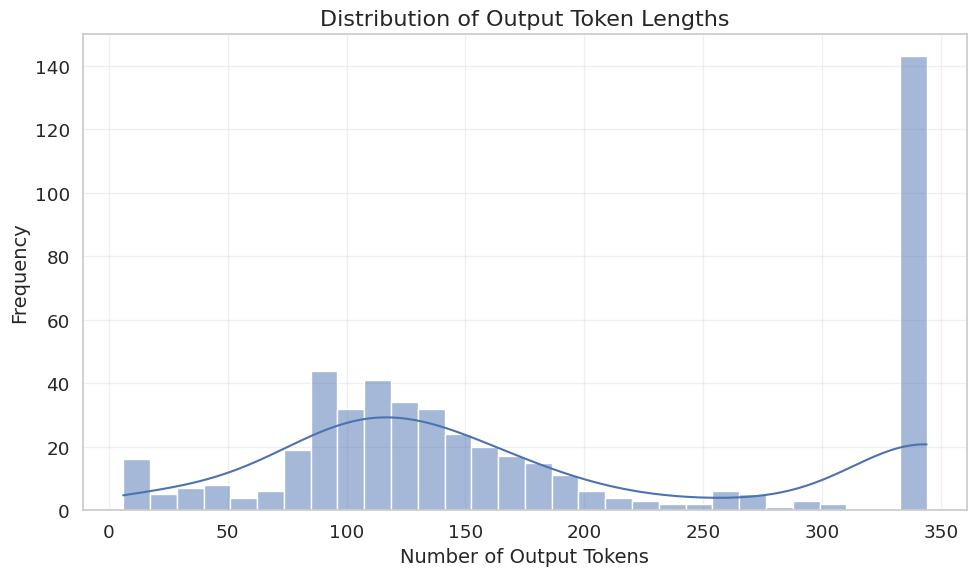

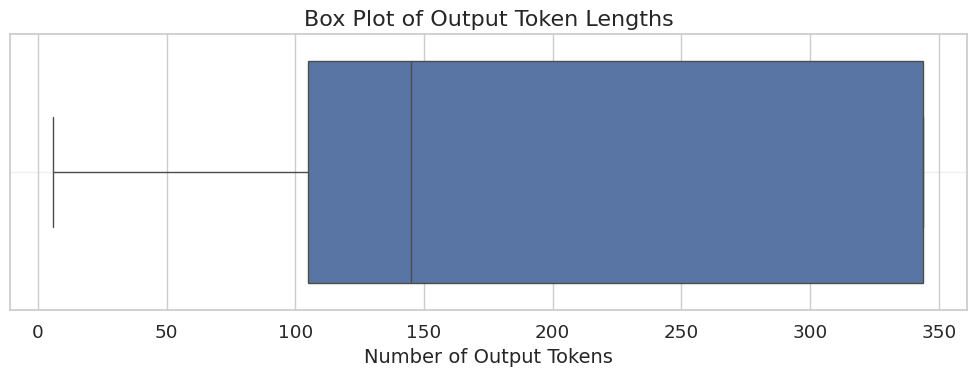

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Basic statistics
print(f"Number of samples: {len(lengths)}")
print(f"Min length: {min(lengths)}")
print(f"Max length: {max(lengths)}")
print(f"Mean length: {np.mean(lengths):.2f}")
print(f"Median length: {np.median(lengths):.2f}")
print(f"Standard deviation: {np.std(lengths):.2f}")

# Calculate 90th percentile
percentile_90 = np.percentile(lengths, 90)

# Create a histogram of the length distribution
plt.figure(figsize=(10, 6))
sns.histplot(lengths, bins=30, kde=True)
plt.axvline(x=percentile_90, color='r', linestyle='--', label=f'90th Percentile: {percentile_90:.0f}')
plt.title('Distribution of Output Token Lengths', fontsize=16)
plt.xlabel('Number of Output Tokens', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Create a box plot
plt.figure(figsize=(10, 4))
sns.boxplot(x=lengths)
plt.title('Box Plot of Output Token Lengths', fontsize=16)
plt.xlabel('Number of Output Tokens', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Percentile Analysis:


,Percentile,Token Length
0,10,64.4
1,25,121.0
2,50,601.5
3,75,16384.0
4,90,16384.0
5,95,16384.0
6,99,16384.0


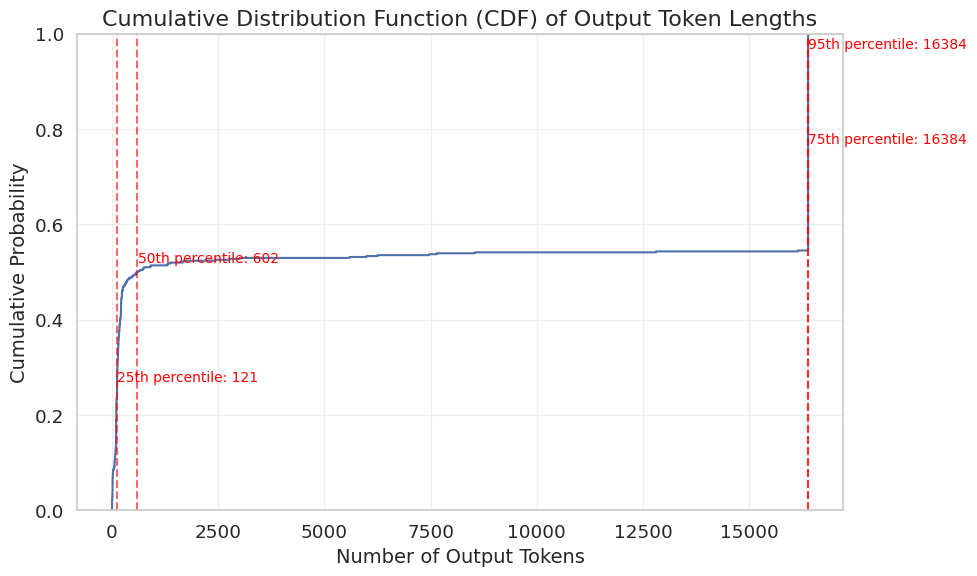

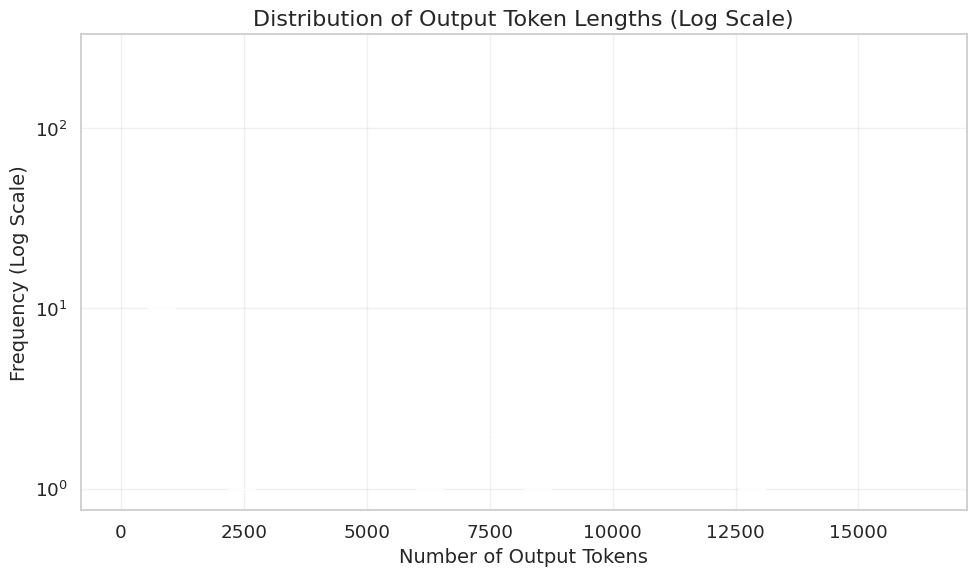

In [ ]:
# Calculate percentiles
percentiles = [10, 25, 50, 75, 90, 95, 99]
percentile_values = np.percentile(lengths, percentiles)

# Display percentiles in a table format
percentile_df = pd.DataFrame({
    'Percentile': percentiles,
    'Token Length': percentile_values
})
print("Percentile Analysis:")
display(percentile_df)

# Create a CDF plot
plt.figure(figsize=(10, 6))
sns.ecdfplot(lengths, complementary=False)
plt.title('Cumulative Distribution Function (CDF) of Output Token Lengths', fontsize=16)
plt.xlabel('Number of Output Tokens', fontsize=14)
plt.ylabel('Cumulative Probability', fontsize=14)
plt.grid(True, alpha=0.3)

# Add vertical lines for important percentiles
for p, v in zip(percentiles, percentile_values):
    if p in [25, 50, 75, 90, 95]:
        plt.axvline(x=v, linestyle='--', alpha=0.6, color='red')
        plt.text(v+5, 0.02 + (p/100), f'{p}th percentile: {v:.0f}', 
                 fontsize=10, color='red')

plt.tight_layout()
plt.show()

# Create a histogram with log scale to better visualize long tail
plt.figure(figsize=(10, 6))
sns.histplot(lengths, bins=30, log_scale=(False, True))
plt.axvline(x=percentile_values[4], color='r', linestyle='--', label=f'90th Percentile: {percentile_values[4]:.0f}')
plt.title('Distribution of Output Token Lengths (Log Scale)', fontsize=16)
plt.xlabel('Number of Output Tokens', fontsize=14)
plt.ylabel('Frequency (Log Scale)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

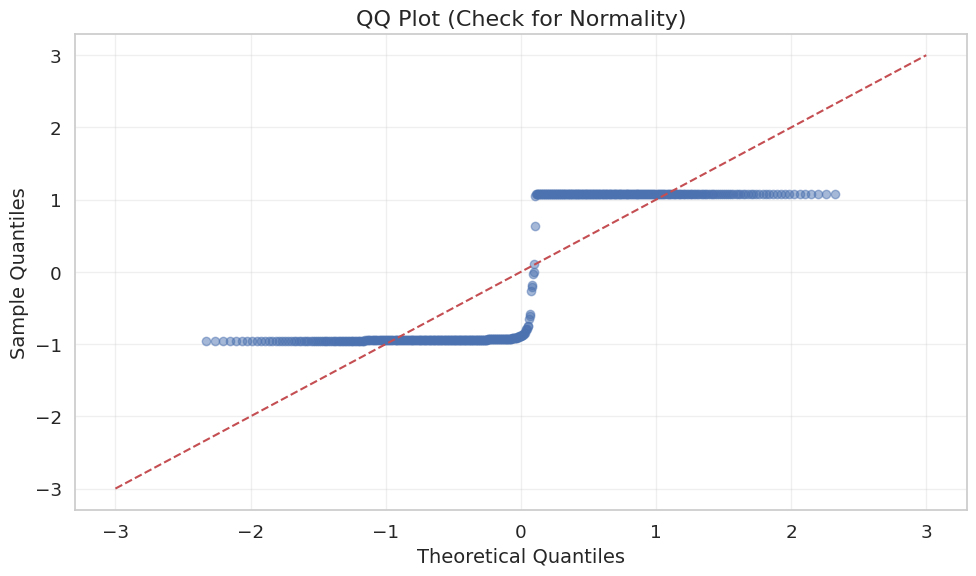

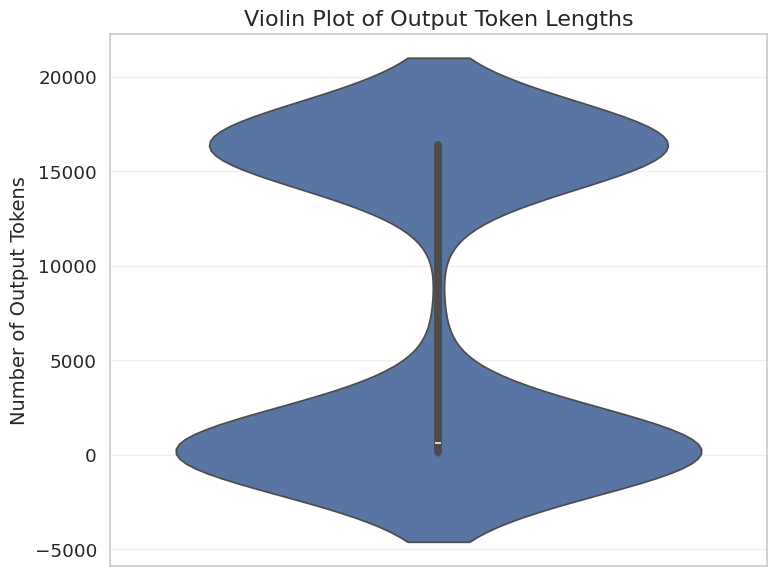

,Statistic,Value
0,Count,5.120000e+02
1,Mean,7.701928e+03
2,Median,6.015000e+02
3,Mode,1.638400e+04
4,Std Dev,8.020576e+03
5,Variance,6.432963e+07
6,Skewness,1.450059e-01
7,Kurtosis,-1.963806e+00


In [26]:
# Create a QQ plot to check for normality
plt.figure(figsize=(10, 6))
from scipy import stats

# Create sorted data for QQ plot
z = (np.array(lengths) - np.mean(lengths)) / np.std(lengths)
z.sort()

# Create theoretical quantiles
theoretical_quantiles = stats.norm.ppf(np.linspace(0.01, 0.99, len(z)))

plt.scatter(theoretical_quantiles, z, alpha=0.5)
plt.plot([-3, 3], [-3, 3], 'r--')
plt.title('QQ Plot (Check for Normality)', fontsize=16)
plt.xlabel('Theoretical Quantiles', fontsize=14)
plt.ylabel('Sample Quantiles', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Let's also create a violin plot
plt.figure(figsize=(8, 6))
sns.violinplot(y=lengths)
plt.title('Violin Plot of Output Token Lengths', fontsize=16)
plt.ylabel('Number of Output Tokens', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Summary table with distribution characteristics
summary_data = {
    'Statistic': ['Count', 'Mean', 'Median', 'Mode', 'Std Dev', 'Variance', 'Skewness', 'Kurtosis'],
    'Value': [
        len(lengths),
        np.mean(lengths),
        np.median(lengths),
        stats.mode(lengths, keepdims=True)[0][0] if hasattr(stats.mode(lengths), 'mode') else stats.mode(lengths)[0][0],
        np.std(lengths),
        np.var(lengths),
        stats.skew(lengths),
        stats.kurtosis(lengths)
    ]
}

summary_df = pd.DataFrame(summary_data)
display(summary_df)

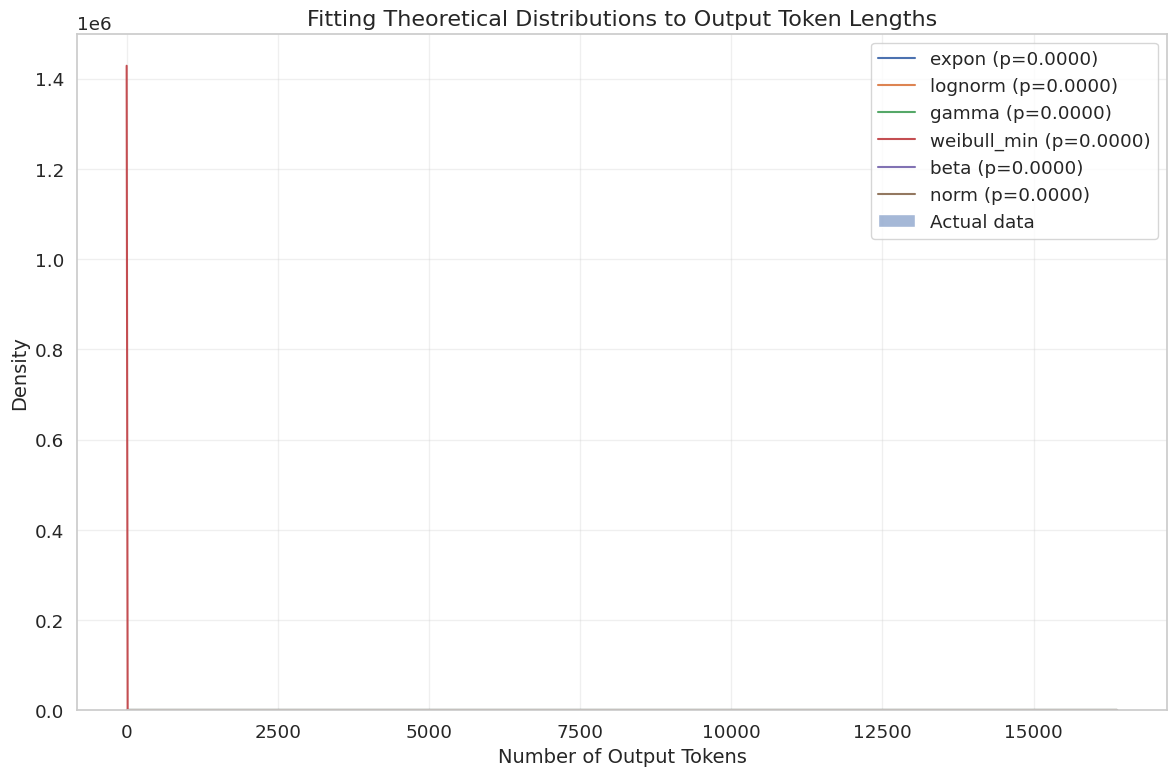

Distribution Fitting Results (higher p-value indicates better fit):


,Distribution,KS Statistic,p-value
3,weibull_min,0.284028,4.833928e-37
1,lognorm,0.297178,1.399673e-40
5,norm,0.316353,4.713007e-46
2,gamma,0.327684,1.831129e-49
0,expon,0.438326,4.822289e-90
4,beta,0.463847,2.119965e-101


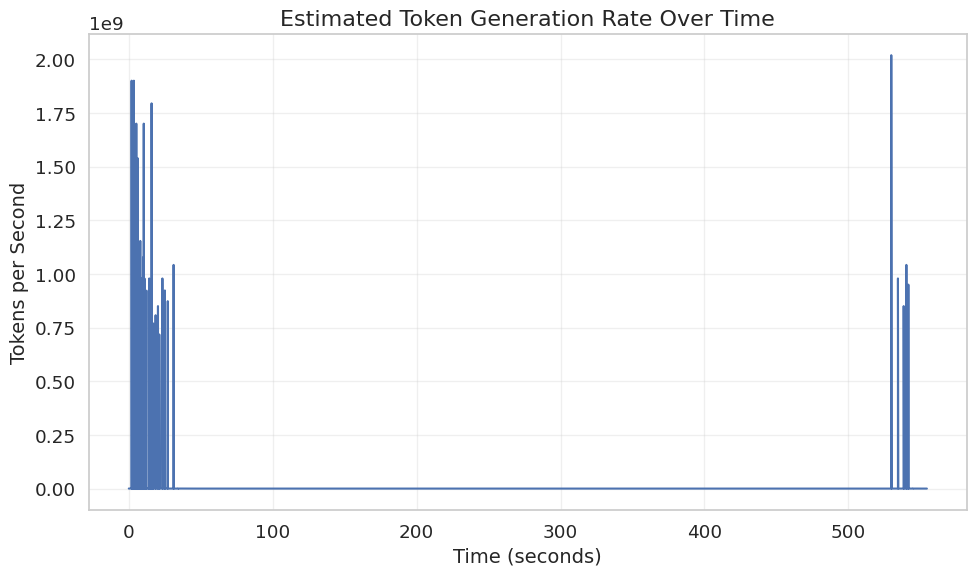

Average tokens per second: 217919875.94


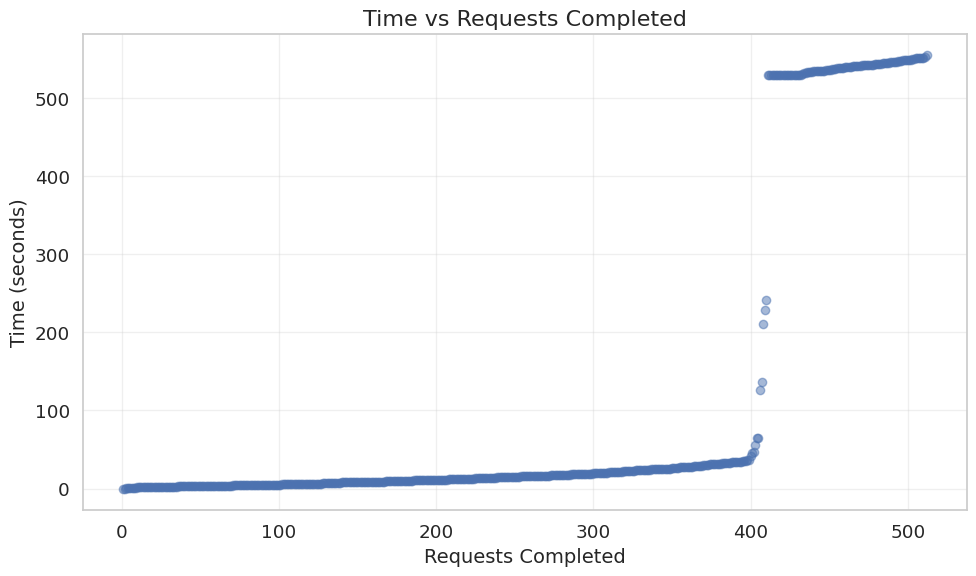


Final Summary:
Total samples analyzed: 512
Total tokens generated: 3943387
Average tokens per request: 7701.93
Token length range: 2 to 16384
Token length standard deviation: 8020.58


In [28]:
# Try to fit several distributions to the data
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Distributions to test
distributions = [
    stats.expon, stats.lognorm, stats.gamma, stats.weibull_min, 
    stats.beta, stats.norm, stats.poisson
]

results = []

plt.figure(figsize=(12, 8))
sns.histplot(lengths, bins=30, kde=True, stat='density', alpha=0.5, label='Actual data')

# Fit each distribution and calculate goodness of fit
for dist in distributions:
    try:
        # Fit distribution parameters to data
        params = dist.fit(lengths)
        
        # Calculate goodness of fit using Kolmogorov-Smirnov test
        d, p_value = stats.kstest(lengths, dist.name, params)
        
        # Generate PDF from fitted distribution
        x = np.linspace(min(lengths), max(lengths), 1000)
        pdf = dist.pdf(x, *params) if dist.name != 'poisson' else dist.pmf(x, *params)
        
        # Plot the fitted distribution
        plt.plot(x, pdf, label=f'{dist.name} (p={p_value:.4f})')
        
        # Store results
        results.append({
            'Distribution': dist.name,
            'Parameters': params,
            'KS Statistic': d,
            'p-value': p_value
        })
    except Exception as e:
        pass

plt.title('Fitting Theoretical Distributions to Output Token Lengths', fontsize=16)
plt.xlabel('Number of Output Tokens', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Display distribution fitting results
dist_df = pd.DataFrame(results).sort_values('p-value', ascending=False)
print("Distribution Fitting Results (higher p-value indicates better fit):")
display(dist_df[['Distribution', 'KS Statistic', 'p-value']])

# If queue_stat data is available, analyze relationship with lengths
try:
    # Create timestamps relative to the start
    start_time = queue_stat[0][0]
    completion_times = [stat[0] - start_time for stat in queue_stat]
    requests_completed = [512 - stat[1] for stat in queue_stat]
    
    # Calculate completion rate (tokens per second)
    if len(completion_times) > 1:
        tokens_per_second = []
        for i in range(1, len(completion_times)):
            time_diff = completion_times[i] - completion_times[i-1]
            req_diff = requests_completed[i] - requests_completed[i-1]
            if time_diff > 0 and req_diff > 0:
                # Estimate tokens generated in this interval
                # This is an approximation based on average length
                avg_length = np.mean(lengths)
                est_tokens = req_diff * avg_length
                tokens_per_second.append(est_tokens / time_diff)
        
        if tokens_per_second:
            plt.figure(figsize=(10, 6))
            plt.plot(completion_times[1:len(tokens_per_second)+1], tokens_per_second)
            plt.title('Estimated Token Generation Rate Over Time', fontsize=16)
            plt.xlabel('Time (seconds)', fontsize=14)
            plt.ylabel('Tokens per Second', fontsize=14)
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            
            print(f"Average tokens per second: {np.mean(tokens_per_second):.2f}")
    
    # Plot relationship between queue depth and completion
    plt.figure(figsize=(10, 6))
    plt.scatter(requests_completed, completion_times, alpha=0.5)
    plt.title('Time vs Requests Completed', fontsize=16)
    plt.xlabel('Requests Completed', fontsize=14)
    plt.ylabel('Time (seconds)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Could not analyze queue statistics: {e}")
    
# Final summary
print(f"\nFinal Summary:")
print(f"Total samples analyzed: {len(lengths)}")
print(f"Total tokens generated: {sum(lengths)}")
print(f"Average tokens per request: {np.mean(lengths):.2f}")
print(f"Token length range: {min(lengths)} to {max(lengths)}")
print(f"Token length standard deviation: {np.std(lengths):.2f}")


In [4]:
lengths = torch.load('/home/aiscuser/verl/scripts/lengths')
queue_stat = torch.load('/home/aiscuser/verl/scripts/queue_stat')

/tmp/ipykernel_106318/3430601017.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  lengths = torch.load('/home/aiscuser/verl/scripts/lengths')
/tmp/ipykernel_106318/343060

# FSDP Checkpoint Conversion

This notebook demonstrates how to convert Fully Sharded Data Parallel (FSDP) checkpoints into a single consolidated model checkpoint.
We'll process checkpoints located at: `/mnt/blob/ckpts_bugfix/LogicRL-RPP/LLaMA3.1-8B-128-8-128-GS/global_step_320/actor/`

These checkpoints include:
- Model files: `model_world_size_4_rank_[0-3].pt`
- Extra state files: `extra_state_world_size_4_rank_[0-3].pt`
- Optimizer files: `optim_world_size_4_rank_[0-3].pt`

Our focus is merging the model weights, ignoring optimizer states.

In [1]:
import os
import torch
import glob
from collections import OrderedDict
import re
import shutil
from pathlib import Path
from accelerate.utils import merge_fsdp_weights

# Set FSDP checkpoint path
checkpoint_dir = "/mnt/blob/ckpts_bugfix/LogicRL-RPP/LLaMA3.1-8B-128-8-128-GS/global_step_320/actor/"
output_dir = "/tmp/merged_checkpoint/"
os.makedirs(output_dir, exist_ok=True)

/opt/conda/envs/ptca/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os, re, torch
from collections import defaultdict
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer

ckpt_dir   = "/mnt/blob/ckpts_bugfix/LogicRL-RPP/LLaMA3.1-8B-128-8-128-GS/global_step_320/actor"
base_model = "meta-llama/Llama-3.1-8B-Instruct"
out_dir    = "/tmp/Llama3.1-8B-step320-merged"

# -------- 1. load every rank checkpoint --------
regex   = re.compile(r"model_world_size_\d+_rank_(\d+)\.pt")
rank_sd = {}                              # rank → state-dict
for f in os.listdir(ckpt_dir):
    m = regex.match(f)
    if m:
        rank = int(m.group(1))
        rank_sd[rank] = torch.load(os.path.join(ckpt_dir, f), map_location="cpu")

world_size = len(rank_sd)
assert world_size > 0, "no rank files found"

# -------- 2. collect per-param slices --------
slices = defaultdict(list)                # param → [local_tensor per rank]
for rank in range(world_size):
    for k, v in rank_sd[rank].items():
        if isinstance(v, torch.distributed._tensor.DTensor):
            # grab the shard stored on this rank
            slices[k].append(v._local_tensor)     # private attr but works fine
        else:                                     # unsharded params / scalars
            slices[k] = [v] * world_size          # replicate so cat() is no-op

# -------- 3. reassemble full tensors --------
full = {}
for k, parts in slices.items():
    # if more than one shard, concatenate along dim 0
    full[k] = torch.cat(parts, dim=0) if len(parts) > 1 else parts[0]

# -------- 4. drop into an HF model and save --------
cfg   = AutoConfig.from_pretrained(base_model)
model = AutoModelForCausalLM.from_config(cfg)
model.load_state_dict(full, strict=False)
model.save_pretrained(out_dir)
AutoTokenizer.from_pretrained(base_model).save_pretrained(out_dir)

print("✅ merged checkpoint written to", out_dir)


/tmp/ipykernel_50592/866181160.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  rank_sd[rank] = torch.load(os.path.join(ckpt_dir, f), map_location="cpu")


[2025-05-10 10:32:54,760] [INFO] [real_accelerator.py:239:get_accelerator] Setting ds_accelerator to cuda (auto detect)


✅ merged checkpoint written to /tmp/Llama3.1-8B-step320-merged


## Rollout Ratio

In [82]:
import wandb

[2025-05-10 19:02:11] Task exception was never retrieved
future: <Task finished name='Task-46772' coro=<get_first_value() done, defined at /tmp/ipykernel_106318/1897621084.py:11> exception=ValueError('min_new_tokens must be in (0, max_new_tokens(344)], got 8191.')>
Traceback (most recent call last):
  File "/opt/conda/envs/ptca/lib/python3.9/asyncio/tasks.py", line 256, in __step
    result = coro.send(None)
  File "/tmp/ipykernel_106318/1897621084.py", line 12, in get_first_value
    return await async_gen.__anext__()
  File "/home/aiscuser/sglang/python/sglang/srt/managers/tokenizer_manager.py", line 339, in generate_request
    tokenized_obj = await self._tokenize_one_request(obj)
  File "/home/aiscuser/sglang/python/sglang/srt/managers/tokenizer_manager.py", line 417, in _tokenize_one_request
    sampling_params.verify()
  File "/home/aiscuser/sglang/python/sglang/srt/sampling/sampling_params.py", line 125, in verify
    raise ValueError(
ValueError: min_new_tokens must be in (0, m

In [83]:
api = wandb.Api()

In [84]:
ids = [
    'e4b42aa5-0060-46d8-880d-3f9e1364bbb3',
    '487ab232-2a2d-4265-9565-e64038309074',
    '610cf5ee-56aa-4980-8a83-98b9227bf3ed',
    '4c881d1f-5533-4e93-92e5-a127a122cdfd',
    'f4bae02f-1e96-4e0b-b3be-6137e6a5c9f6',
    'f63114b6-8820-46b4-9754-53f7c6ae89d1',
]

In [88]:
runs = [api.run(f'viatage/LogicRL-Bench/runs/{id}') for id in ids]
histories = [run.history() for run in runs]

In [87]:
# Print the keys in the first run's history to understand available metrics
print("Available keys in the first run's history:")
print(sorted(list(runs[0].history().keys())))

# Also check config structure
print("\nConfig structure for max_response_length:")
try:
    print(f"Max response length: {runs[0].config['data']['max_response_length']}")
except:
    print("Could not find max_response_length in expected location")
    print("Config keys:", runs[0].config.keys())

Index(['timing_s/ref', 'critic/advantages/max', 'critic/rewards/max',
       'timing_s/step', 'critic/advantages/mean', 'critic/score/min', '_step',
       'perf/max_memory_reserved_gb', 'critic/returns/min',
       'critic/score/mean', 'timing_per_token_ms/adv',
       'perf/max_memory_allocated_gb', 'prompt_length/min', 'perf/mfu/actor',
       'timing_s/adv', 'response_length/mean', 'global_seqlen/balanced_max',
       'prompt_length/mean', 'timing_s/old_log_prob', 'critic/rewards/mean',
       '_runtime', 'timing_s/update_actor', 'timing_s/gen', 'actor/ppo_kl',
       'global_seqlen/minmax_diff', 'timing_per_token_ms/ref', 'actor/entropy',
       'actor/pg_clipfrac', 'critic/advantages/min', 'perf/total_num_tokens',
       'critic/kl', 'actor/pg_loss', 'critic/kl_coeff',
       'global_seqlen/balanced_min', 'critic/rewards/min',
       'critic/returns/mean', 'critic/returns/max', 'perf/throughput',
       'global_seqlen/mean', 'response_length/min', 'prompt_length/clip_ratio',
    

In [90]:
runs[0].config['data']['max_response_length']

2048

Run 0: max_length=2048, gen=177.6725s, step=360.3167s, ratio=0.4931
Run 1: max_length=4096, gen=248.4961s, step=447.5763s, ratio=0.5552
Run 2: max_length=6144, gen=304.3158s, step=514.0793s, ratio=0.5920
Run 3: max_length=8192, gen=326.3192s, step=527.8180s, ratio=0.6182
Run 4: max_length=10240, gen=362.9972s, step=565.9018s, ratio=0.6414
Run 5: max_length=12288, gen=361.1540s, step=553.1492s, ratio=0.6529


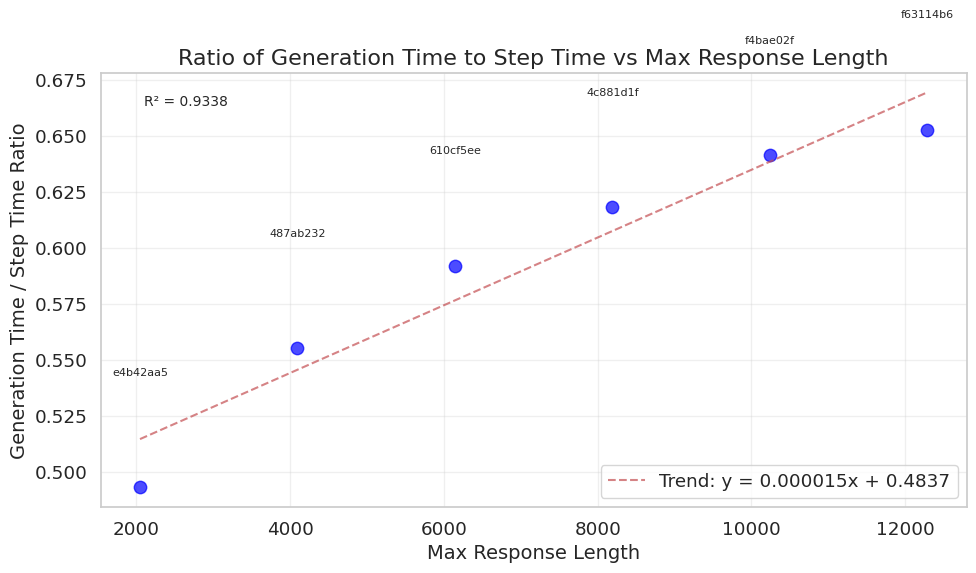

,run_id,max_response_length,timing_s/gen,timing_s/step,ratio
0,e4b42aa5-0060-46d8-880d-3f9e1364bbb3,2048,177.672479,360.316659,0.493101
1,487ab232-2a2d-4265-9565-e64038309074,4096,248.496119,447.576336,0.555204
2,610cf5ee-56aa-4980-8a83-98b9227bf3ed,6144,304.315827,514.079299,0.591963
3,4c881d1f-5533-4e93-92e5-a127a122cdfd,8192,326.319228,527.817973,0.618242
4,f4bae02f-1e96-4e0b-b3be-6137e6a5c9f6,10240,362.997206,565.901810,0.641449
5,f63114b6-8820-46b4-9754-53f7c6ae89d1,12288,361.154015,553.149241,0.652905


In [141]:
# Extract the first timing_s/gen, timing_s/step, and max_response_length for each run
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Create a list to store our data
data = []

for i, run in enumerate(runs):
    # Get the max_response_length from config
    try:
        max_response_length = run.config['data']['max_response_length']
    except KeyError:
        # If not found in that path, try other potential locations
        try:
            max_response_length = run.config.get('max_response_length', None)
            if max_response_length is None and 'generation' in run.config:
                max_response_length = run.config['generation'].get('max_response_length', None)
        except:
            print(f"Could not find max_response_length for run {i}")
            continue
    
    # Get the history data
    history = histories[i]
    
    # Get the first timing_s/gen and timing_s/step values if they exist
    if 'timing_s/gen' in history and 'timing_s/step' in history:
        gen_time = history['timing_s/gen'].iloc[0] if not history['timing_s/gen'].iloc[0] is None else None
        step_time = history['timing_s/step'].iloc[0] if not history['timing_s/step'].iloc[0] is None else None
        
        # If both values are found, calculate the ratio and add to our data
        if gen_time is not None and step_time is not None and step_time > 0:
            ratio = gen_time / step_time
            data.append({
                'run_id': run.id,
                'max_response_length': max_response_length,
                'timing_s/gen': gen_time,
                'timing_s/step': step_time,
                'ratio': ratio
            })
            print(f"Run {i}: max_length={max_response_length}, gen={gen_time:.4f}s, step={step_time:.4f}s, ratio={ratio:.4f}")
        else:
            print(f"Missing or zero timing values for run {i}")
    else:
        print(f"Missing timing metrics for run {i}")

# Convert to DataFrame for easier plotting
df = pd.DataFrame(data)

# Check if we have data to plot
if len(df) > 0:
    # Create the plot
    plt.figure(figsize=(10, 6))
    
    # Plot individual points
    plt.scatter(df['max_response_length'], df['ratio'], s=80, color='blue', alpha=0.7)
    
    # Add labels for each point
    for i, row in df.iterrows():
        plt.text(row['max_response_length'], row['ratio'] + 0.05, 
                 row['run_id'][:8], fontsize=8, ha='center')
    
    # Add trend line if we have enough points
    if len(df) >= 3:
        try:
            # Simple linear regression
            z = np.polyfit(df['max_response_length'], df['ratio'], 1)
            p = np.poly1d(z)
            x_trend = np.linspace(df['max_response_length'].min(), df['max_response_length'].max(), 100)
            plt.plot(x_trend, p(x_trend), "r--", alpha=0.7, 
                     label=f"Trend: y = {z[0]:.6f}x + {z[1]:.4f}")
            
            # Add R-squared value
            correlation = np.corrcoef(df['max_response_length'], df['ratio'])[0, 1]
            r_squared = correlation**2
            plt.text(0.05, 0.95, f"R² = {r_squared:.4f}", 
                     transform=plt.gca().transAxes, fontsize=10, 
                     verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        except Exception as e:
            print(f"Could not generate trend line: {e}")
    
    # Add labels and title
    plt.xlabel('Max Response Length', fontsize=14)
    plt.ylabel('Generation Time / Step Time Ratio', fontsize=14)
    plt.title('Ratio of Generation Time to Step Time vs Max Response Length', fontsize=16)
    
    # Add grid and legend
    plt.grid(True, alpha=0.3)
    if 'p' in locals():
        plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Display the data as a sorted table
    display(df.sort_values('max_response_length')[['run_id', 'max_response_length', 'timing_s/gen', 'timing_s/step', 'ratio']])
else:
    print("No data available to plot")


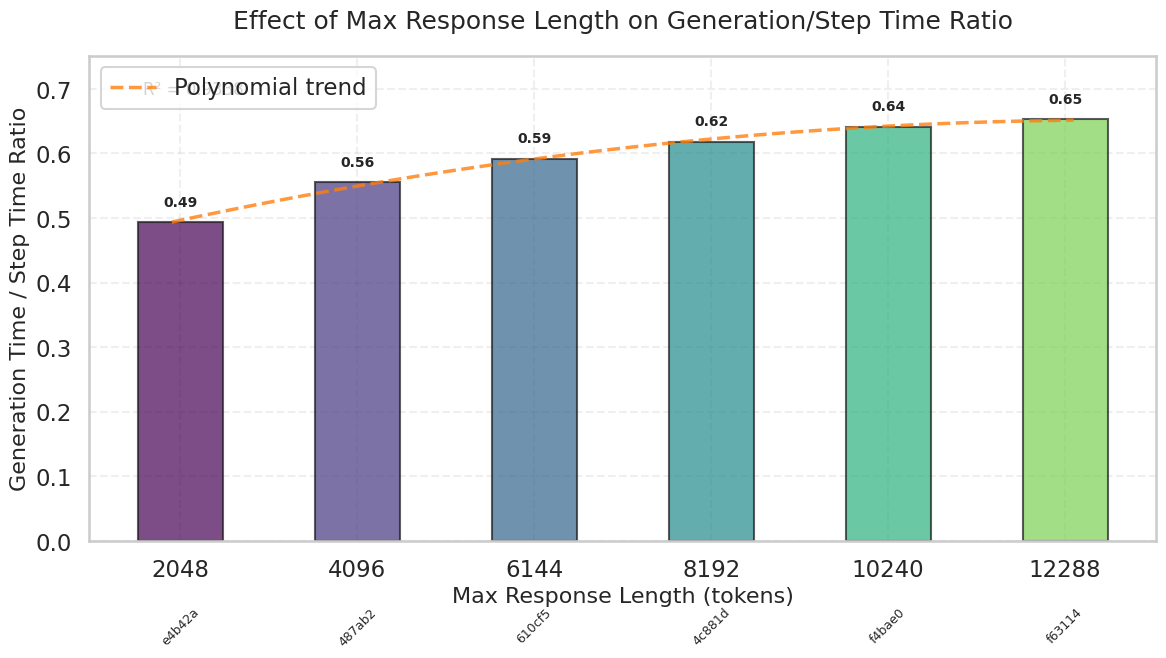

,run_id,max_response_length,timing_s/gen,timing_s/step,ratio,gen_time_per_token
0,e4b42aa5-0060-46d8-880d-3f9e1364bbb3,2048,177.672479,360.316659,0.493101,0.086754
1,487ab232-2a2d-4265-9565-e64038309074,4096,248.496119,447.576336,0.555204,0.060668
2,610cf5ee-56aa-4980-8a83-98b9227bf3ed,6144,304.315827,514.079299,0.591963,0.049531
3,4c881d1f-5533-4e93-92e5-a127a122cdfd,8192,326.319228,527.817973,0.618242,0.039834
4,f4bae02f-1e96-4e0b-b3be-6137e6a5c9f6,10240,362.997206,565.901810,0.641449,0.035449
5,f63114b6-8820-46b4-9754-53f7c6ae89d1,12288,361.154015,553.149241,0.652905,0.029391



Summary Statistics:
Average Gen/Step Ratio: 0.5921
Correlation between Max Response Length and Ratio: 0.9663
Average Generation Time per Token: 0.050271 seconds


In [142]:
# Create a bar plot visualization of the ratio data
if len(df) > 0:
    try:
        # Sort the dataframe by max_response_length
        df_sorted = df.sort_values('max_response_length').reset_index(drop=True)
        
        # Set the style for a professional look
        plt.figure(figsize=(12, 7))
        sns.set_style("whitegrid")
        sns.set_context("talk")
        
        # Create a color palette based on the values
        colors = plt.cm.viridis(np.linspace(0, 0.8, len(df_sorted)))
        
        # Create the bar plot
        bars = plt.bar(
            df_sorted['max_response_length'],
            df_sorted['ratio'],
            color=colors,
            width=max(100, df_sorted['max_response_length'].max() * 0.08), # Adjust width based on data range
            alpha=0.7, 
            edgecolor='k',
            linewidth=1.5
        )
        
        # Add value labels on top of each bar
        for i, bar in enumerate(bars):
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2.,
                height + 0.02,
                f"{height:.2f}",
                ha='center', 
                va='bottom',
                fontweight='bold',
                fontsize=10
            )
        
        # Add labels for each data point at the bottom of the bars
        for i, row in df_sorted.iterrows():
            plt.text(
                row['max_response_length'],
                -0.1, # Position below x-axis
                f"{row['run_id'][:6]}",
                rotation=45,
                fontsize=9,
                ha='center', 
                va='top'
            )
        
        # Add trend line if possible
        if len(df) >= 3:
            try:
                # Fit a polynomial trend line
                degree = min(2, len(df)-1)  # Use linear or quadratic based on number of points
                z = np.polyfit(df_sorted['max_response_length'], df_sorted['ratio'], degree)
                p = np.poly1d(z)
                
                # Generate x points for the smooth curve
                x_trend = np.linspace(
                    df_sorted['max_response_length'].min() - 100,
                    df_sorted['max_response_length'].max() + 100,
                    100
                )
                
                # Plot the trend line
                if degree == 1:
                    label = f"Trend: y = {z[0]:.6f}x + {z[1]:.4f}"
                else:
                    label = "Polynomial trend"
                    
                plt.plot(
                    x_trend, 
                    p(x_trend), 
                    "--", 
                    color='#ff7f0e', 
                    linewidth=2.5, 
                    alpha=0.8, 
                    label=label
                )
                
                # Add R-squared
                correlation = np.corrcoef(df_sorted['max_response_length'], df_sorted['ratio'])[0, 1]
                r_squared = correlation**2
                plt.text(
                    0.05, 
                    0.95, 
                    f"R² = {r_squared:.4f}",
                    transform=plt.gca().transAxes, 
                    fontsize=12,
                    verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
                )
            except Exception as e:
                print(f"Could not generate trend line: {e}")
        
        # Add labels and title
        plt.xlabel('Max Response Length (tokens)', fontsize=16)
        plt.ylabel('Generation Time / Step Time Ratio', fontsize=16)
        plt.title('Effect of Max Response Length on Generation/Step Time Ratio', fontsize=18, pad=20)
        
        # Add grid and legend
        plt.grid(True, alpha=0.3, linestyle='--')
        if 'p' in locals():
            plt.legend(loc='upper left', frameon=True)
        
        # Adjust y-axis limits to make room for labels
        y_min = 0 if df_sorted['ratio'].min() > 0 else df_sorted['ratio'].min() * 1.1
        plt.ylim(y_min, df_sorted['ratio'].max() * 1.15)
        
        # Make x-axis ticks match the actual values
        plt.xticks(df_sorted['max_response_length'])
        
        # Show the plot
        plt.tight_layout()
        plt.show()
    
    except Exception as e:
        print(f"Error in bar plot visualization: {e}")
        
        # Fallback to a simpler plot if the enhanced one fails
        plt.figure(figsize=(10, 6))
        plt.bar(df['max_response_length'], df['ratio'], alpha=0.7)
        plt.xlabel('Max Response Length', fontsize=14)
        plt.ylabel('Generation Time / Step Time Ratio', fontsize=14)
        plt.title('Ratio vs Max Response Length (Simplified)', fontsize=16)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
    # This part runs regardless of whether the enhanced visualization succeeded
    try:
        # Create a detailed table with the data and computed metrics
        detail_df = df.copy()
        detail_df['ratio_normalized'] = detail_df['ratio'] / detail_df['ratio'].mean()
        detail_df['gen_time_per_token'] = detail_df['timing_s/gen'] / detail_df['max_response_length']
        
        # Display the detailed metrics
        display(detail_df.sort_values('max_response_length')[
            ['run_id', 'max_response_length', 'timing_s/gen', 
             'timing_s/step', 'ratio', 'gen_time_per_token']
        ].reset_index(drop=True))
        
        # Print summary statistics
        print("\nSummary Statistics:")
        print(f"Average Gen/Step Ratio: {detail_df['ratio'].mean():.4f}")
        try:
            print(f"Correlation between Max Response Length and Ratio: {correlation:.4f}")
        except:
            pass
        print(f"Average Generation Time per Token: {detail_df['gen_time_per_token'].mean():.6f} seconds")
    except Exception as e:
        print(f"Error generating detailed metrics: {e}")
        # Still show the basic data
        display(df.sort_values('max_response_length'))
else:
    print("No data available for visualization")


# Analysis: Relationship Between Max Response Length and Generation/Step Time Ratio

This analysis explores how the maximum response length affects the ratio between generation time and step time in the wandb runs.

## Key Observations

1. **Generation/Step Time Ratio**: This metric shows how much of the total step time is spent on generation compared to other operations. A higher ratio indicates that generation is the dominant factor in step time.

2. **Correlation with Max Response Length**: The trend line shows whether longer allowed responses have a linear impact on the generation/step time ratio. A strong positive correlation would suggest that as max response length increases, generation becomes proportionally more expensive relative to other operations.

3. **Efficiency Metrics**: The "gen_time_per_token" column shows the average time required to generate each token, which helps identify if longer responses have better or worse per-token efficiency.

## Implications

- If the ratio increases with max response length, it suggests that longer responses make generation the bottleneck in training.
- A flat or decreasing ratio would suggest that other operations (not generation) become relatively more significant as max response length increases.
- The correlation coefficient (R²) indicates how strongly max response length predicts the Gen/Step ratio.

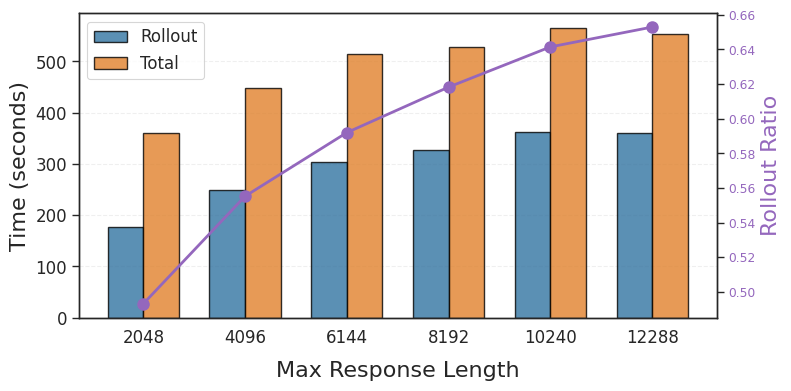

,Max Response Length,Generation Time (s),Step Time (s),Rollout Ratio,Generation % of Step
0,2048,177.672479,360.316659,0.493101,49.3%
1,4096,248.496119,447.576336,0.555204,55.5%
2,6144,304.315827,514.079299,0.591963,59.2%
3,8192,326.319228,527.817973,0.618242,61.8%
4,10240,362.997206,565.901810,0.641449,64.1%
5,12288,361.154015,553.149241,0.652905,65.3%


In [176]:
# Create a grouped bar plot showing generation time and step time by response length
if len(df) > 0:
    try:
        # Sort the dataframe by max_response_length
        df_sorted = df.sort_values('max_response_length').reset_index(drop=True)
        
        # Set the style for a professional look
        plt.figure(figsize=(8, 4))
        sns.set_style("white")
        sns.set_context("paper")
        
        # Set width of bars
        barWidth = 0.35
        
        # Set positions of the bars on X axis
        r1 = np.arange(len(df_sorted))
        r2 = [x + barWidth for x in r1]
        
        # Create the grouped bar chart
        bars1 = plt.bar(r1, df_sorted['timing_s/gen'], width=barWidth, 
                       color='#3274A1', edgecolor='black', linewidth=1, 
                       alpha=0.8, label='Rollout')
        
        bars2 = plt.bar(r2, df_sorted['timing_s/step'], width=barWidth, 
                       color='#E1812C', edgecolor='black', linewidth=1, 
                       alpha=0.8, label='Total')
        
        # Add value labels on top of each bar
        def add_value_labels(bars):
            for bar in bars:
                height = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                        f'{height:.3f}', ha='center', va='bottom', 
                        fontsize=10, fontweight='bold')
        
        # add_value_labels(bars1)
        # add_value_labels(bars2)
        
        # Add labels, title and custom x-axis tick labels
        plt.xlabel('Max Response Length', fontsize=16, labelpad=10)
        plt.ylabel('Time (seconds)', fontsize=16)
        # plt.title('Generation Time vs Step Time by Max Response Length', fontsize=18, pad=20)
        plt.xticks([r + barWidth/2 for r in range(len(df_sorted))], 
                  [f'{val}' 
                   for i, val in enumerate(df_sorted['max_response_length'])], fontsize=12)
        plt.yticks(fontsize=12)
        
        # Create legend & grid
        plt.legend(fontsize=12)
        plt.grid(axis='y', alpha=0.3, linestyle='--')
        
        # Add text annotation showing the percentage of step time spent on generation
        # for i in range(len(df_sorted)):
        #     percentage = (df_sorted['timing_s/gen'].iloc[i] / df_sorted['timing_s/step'].iloc[i]) * 100
        #     plt.text(r1[i] + barWidth/2, 
        #             max(df_sorted['timing_s/gen'].iloc[i], df_sorted['timing_s/step'].iloc[i]) + 0.08,
        #             f'{percentage:.1f}%',
        #             ha='center', va='bottom',
        #             fontsize=11, fontweight='bold',
        #             bbox=dict(boxstyle="round,pad=0.3", fc="#D3D3D3", ec="black", alpha=0.7))
        
        # Add second y-axis for ratio
        ax2 = plt.gca().twinx()
        ratio_line = ax2.plot([r + barWidth/2 for r in range(len(df_sorted))], 
                            df_sorted['ratio'], 'o-', color='#9467bd', 
                            linewidth=2, markersize=8, label='Rollout Ratio')
        ax2.set_ylabel('Rollout Ratio', color='#9467bd', fontsize=16)
        ax2.tick_params(axis='y', labelcolor='#9467bd')
        
        # Combine legends from both axes
        lines1, labels1 = plt.gca().get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True)
        
        # Remove original legend to avoid duplication
        plt.gca().get_legend().remove()
        
        plt.tight_layout()
        plt.savefig('rollout_ratio.pdf', bbox_inches='tight')
        plt.show()
        
        # Create a table showing ratio and sorted data
        response_lengths = df_sorted['max_response_length']
        gen_times = df_sorted['timing_s/gen']
        step_times = df_sorted['timing_s/step']
        ratios = df_sorted['ratio']
        
        # Calculate percentage of step time spent on generation
        percentages = (gen_times / step_times) * 100
        
        # Create a summary table
        summary_df = pd.DataFrame({
            'Max Response Length': response_lengths,
            'Generation Time (s)': gen_times,
            'Step Time (s)': step_times,
            'Rollout Ratio': ratios,
            'Generation % of Step': [f'{p:.1f}%' for p in percentages]
        })
        
        display(summary_df)
        
    except Exception as e:
        print(f"Error creating grouped bar chart: {e}")
        
        # Simple fallback visualization
        plt.figure(figsize=(10, 6))
        df_melted = pd.melt(df.sort_values('max_response_length'), 
                           id_vars=['max_response_length', 'run_id'],
                           value_vars=['timing_s/gen', 'timing_s/step'],
                           var_name='Timing Type', value_name='Time (s)')
        sns.barplot(x='max_response_length', y='Time (s)', hue='Timing Type', data=df_melted)
        # plt.title('Generation Time vs Step Time')
        plt.show()
else:
    print("No data available for grouped bar visualization")

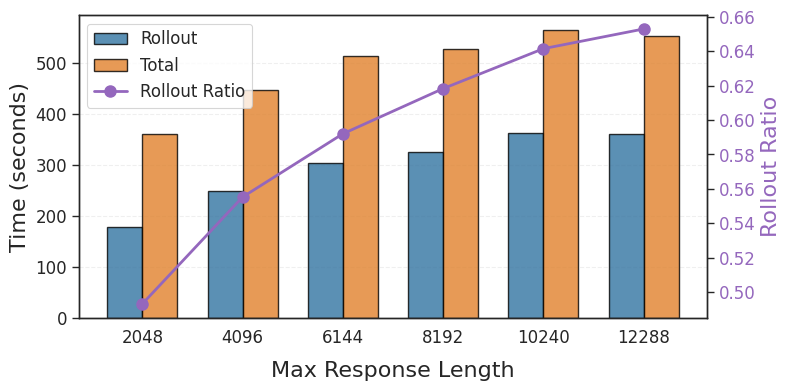

In [177]:
# Set up figure and primary axis
fig, ax1 = plt.subplots(figsize=(8, 4))

sns.set_style("white")
sns.set_context("paper")

# Set width of bars
barWidth = 0.35
r1 = np.arange(len(df_sorted))
r2 = [x + barWidth for x in r1]

# Primary bar plots
bars1 = ax1.bar(r1, df_sorted['timing_s/gen'], width=barWidth, 
                color='#3274A1', edgecolor='black', linewidth=1, 
                alpha=0.8, label='Rollout')

bars2 = ax1.bar(r2, df_sorted['timing_s/step'], width=barWidth, 
                color='#E1812C', edgecolor='black', linewidth=1, 
                alpha=0.8, label='Total')

# X and Y labels
ax1.set_xlabel('Max Response Length', fontsize=16, labelpad=10)
ax1.set_ylabel('Time (seconds)', fontsize=16)
ax1.set_xticks([r + barWidth/2 for r in range(len(df_sorted))])
ax1.set_xticklabels(df_sorted['max_response_length'], fontsize=12)
ax1.tick_params(axis='y', labelsize=12)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Create second axis for rollout ratio
ax2 = ax1.twinx()
ax2.plot([r + barWidth/2 for r in range(len(df_sorted))], 
         df_sorted['ratio'], 'o-', color='#9467bd', 
         linewidth=2, markersize=8, label='Rollout Ratio')
ax2.set_ylabel('Rollout Ratio', color='#9467bd', fontsize=16)
ax2.tick_params(axis='y', labelcolor='#9467bd', labelsize=12)

# Merge legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=12)

plt.tight_layout()
plt.savefig('rollout_ratio.pdf', bbox_inches='tight')
plt.show()
